In [16]:
import matplotlib
import numpy as np
import sys
import matplotlib.pyplot as plt
from collections import defaultdict
import gymnasium as gym
import numpy as np

from collections import defaultdict

In [17]:
env = gym.make('CliffWalking-v0', is_slippery=False)

In [32]:
def plot_result(total_rewards, cumulative_regrets, num_episodes, num_runs=1, figsize=(15, 6), title='Off-Policy Monte Carlo', color='blue'):
    """Plot the total rewards and cumulative regrets in subplots."""
    # Create a figure with two subplots
    fig, axs = plt.subplots(2, 1, figsize=figsize)
    
    # Plot total rewards
    axs[0].plot(total_rewards, label='Total Rewards', color=color)
    axs[0].set_title('Total Rewards')
    # axs[0].set_xlabel('Episode')
    axs[0].set_ylabel('Total Reward')
    axs[0].legend()

    axs[1].plot(cumulative_regrets, label='Cumulative Regrets', color=color)
    axs[1].set_title('Cumulative Regrets')
    axs[1].set_xlabel('Episode')
    axs[1].set_ylabel('Cumulative Regret')
    axs[1].legend()

    plt.suptitle(title)

    plt.show()



In [19]:
def cumulative_regret(regret_per_run):
  cumulative_sum = 0
  cumulative_regret = []
  for value in regret_per_run:
      cumulative_sum += value
      cumulative_regret.append(cumulative_sum)
  return cumulative_regret

In [20]:
class off_policy_MonteCarlo:
  def __init__(self, env, epsilon=0.1, epsilon_decay=1):
    self.env = env
    self.state_size = env.observation_space.n
    self.action_size = env.action_space.n
    # self.max_time=100
    self.discount_factor=1.0
    self.epsilon_decay = epsilon_decay
    self.epsilon = epsilon
    self.epsilon_init = epsilon
    self.Q = defaultdict(lambda: np.zeros(env.action_space.n))
    self.C = defaultdict(lambda: np.zeros(env.action_space.n))

  def create_behaviour_policy(self, state):
    A = np.ones(self.action_size, dtype=float) * self.epsilon / (self.action_size - 1)
    best_action = np.argmax(self.Q[state])
    A[best_action] += (1.0 - self.epsilon)
    return A

  def create_target_policy(self, state):
    A = np.zeros_like(self.Q[state], dtype=float)
    best_action = np.argmax(self.Q[state])
    A[best_action] = 1.0
    return A

  def get_epsilon_action(self, probs):
    max_prob = np.max(probs)



  def train(self, num_episodes, discount=1.0, debug=True):
    regrets = []
    total_rewards = []
    for i_episode in range(1, num_episodes + 1):
      if debug:
        if i_episode % 10000 == 0:
          print("\rEpisode {}/{}.".format(i_episode, num_episodes))
      state = self.env.reset()
      state = 36
      episode = []
      self.epsilon = self.epsilon_init
      for t in range(500):
        probs = self.create_behaviour_policy(state)

        # if state == 36:
        #   action = 0
        # else:
        normalized_probs = [p / sum(probs) for p in probs]
        action = np.random.choice(len(probs), p=normalized_probs)
        next_state, reward, done, truncated, _ = env.step(action)
        episode.append((state, action, reward))
        self.epsilon = max(0.05, self.epsilon * self.epsilon_decay)
        if done or truncated:
          break
        state = next_state

      G = 0.0
      W = 1.0

      for t in range(len(episode))[::-1]:
        state, action, reward = episode[t]
        G = discount * G + reward
        self.C[state][action] += W
        self.Q[state][action] += (W / self.C[state][action]) * (G - self.Q[state][action])

        if action != np.argmax(self.create_target_policy(state)):
          break
        # W = W * (target_policy(state)[action] / self.create_behaviour_policy(state)[action])
        W = W * 1. / self.create_behaviour_policy(state)[action]

        if W == 0:
          break

      rewards = sum(x[2] for x in episode)
      regret = -13 - rewards
      regrets.append(regret)
      total_rewards.append(rewards)

    return self.Q, regrets, total_rewards

In [42]:
# behaviour_policy = create_behaviour_policy(env.action_space.n)
num_episodes = 10000
agent = off_policy_MonteCarlo(env, epsilon=0.1, epsilon_decay=1)
Q, regrets, total_rewards = agent.train(num_episodes=num_episodes, debug=True)

Episode 10000/10000.


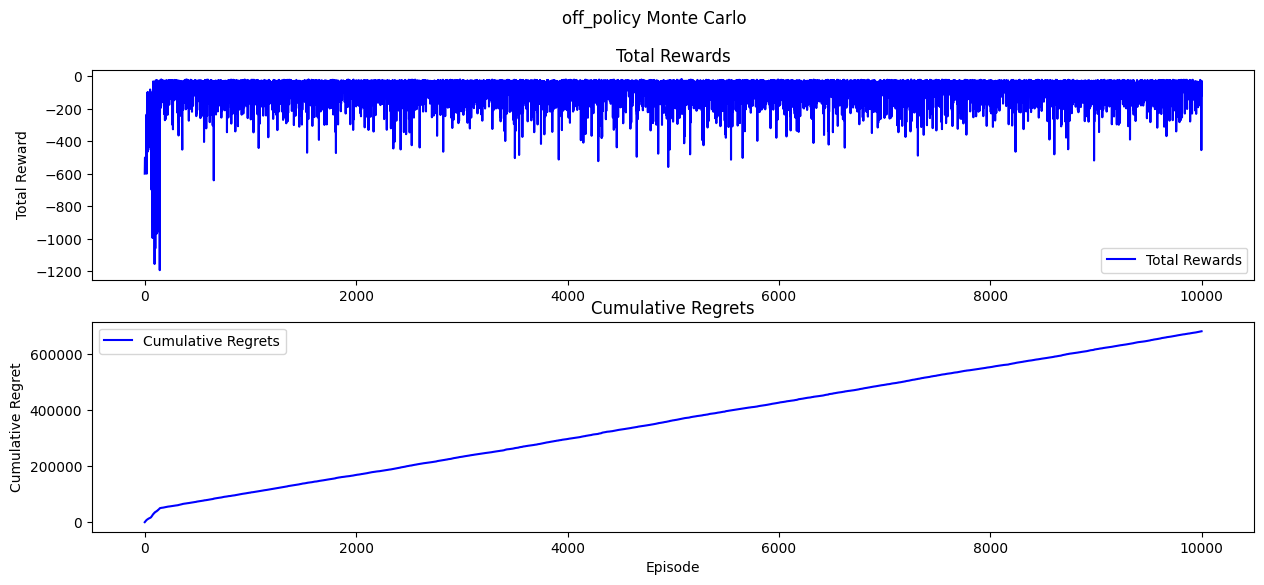

In [43]:
cumulative_regrets = cumulative_regret(regrets)
plot_result(total_rewards, cumulative_regrets, num_episodes , num_runs=1,
              figsize = (15, 6), title = 'off_policy Monte Carlo', color='blue')

In [23]:
def evaluate_Q(Q):
  state = env.reset()
  state = 36
  rewards = 0
  for t in range(500):
    action = np.argmax(Q[state])
    next_state, reward, done, truncated, _ = env.step(action)
    rewards += reward
    state = next_state
    if done:
      return rewards
  return rewards

t = evaluate_Q(Q)

print(Q)

defaultdict(<function off_policy_MonteCarlo.__init__.<locals>.<lambda> at 0x00000248A5B248B0>, {36: array([  -1.74034077, -100.25641026,   -1.83467931,   -1.81734503]), 24: array([-1.59557828, -1.76304793, -2.        , -1.68181818]), 12: array([-1.95521021, -2.03424099, -2.02930149, -1.98238337]), 0: array([-2.02734896, -2.01299635, -2.0135601 , -2.08171121]), 1: array([-2.22722534, -2.2242573 , -3.03388857, -2.3579515 ]), 13: array([-2.26740785, -2.08028366, -2.43541567, -2.07136584]), 2: array([-2.58034142, -2.5936263 , -2.53424453, -2.58427368]), 3: array([-2.43495692, -2.43647821, -2.4397743 , -2.42208982]), 4: array([-2.48624535, -2.47444717, -2.43886022, -2.48952686]), 16: array([-2.44675676, -2.37097822, -2.47568278, -2.38093062]), 5: array([-2.4260793 , -2.73159201, -2.42408127, -2.37237449]), 6: array([-1.93623968, -1.95450942, -2.03447593, -1.93264702]), 7: array([-2.12688292, -2.29073432, -2.06270126, -2.13118144]), 19: array([-2.38093062, -2.32051865, -2.40130353, -2.329833

In [24]:
print(Q)

defaultdict(<function off_policy_MonteCarlo.__init__.<locals>.<lambda> at 0x00000248A5B248B0>, {36: array([  -1.74034077, -100.25641026,   -1.83467931,   -1.81734503]), 24: array([-1.59557828, -1.76304793, -2.        , -1.68181818]), 12: array([-1.95521021, -2.03424099, -2.02930149, -1.98238337]), 0: array([-2.02734896, -2.01299635, -2.0135601 , -2.08171121]), 1: array([-2.22722534, -2.2242573 , -3.03388857, -2.3579515 ]), 13: array([-2.26740785, -2.08028366, -2.43541567, -2.07136584]), 2: array([-2.58034142, -2.5936263 , -2.53424453, -2.58427368]), 3: array([-2.43495692, -2.43647821, -2.4397743 , -2.42208982]), 4: array([-2.48624535, -2.47444717, -2.43886022, -2.48952686]), 16: array([-2.44675676, -2.37097822, -2.47568278, -2.38093062]), 5: array([-2.4260793 , -2.73159201, -2.42408127, -2.37237449]), 6: array([-1.93623968, -1.95450942, -2.03447593, -1.93264702]), 7: array([-2.12688292, -2.29073432, -2.06270126, -2.13118144]), 19: array([-2.38093062, -2.32051865, -2.40130353, -2.329833